# 06 — Fair forecast and policy comparisons

A forecast is not a policy, and a policy is not a forecast. This tutorial separates those choices on a five-SKU panel, then deliberately combines one forecast choice with one policy choice. Every result is conditional on the displayed demand, opening state, timing, costs, and evaluation window.

**Timing migration.** Decisions now precede current demand. `lead_time=0` means immediate receipt; positive lead times count forward from the decision epoch. Decision schedules use zero-based demand periods, while state/callback periods retain their existing coordinates. Forecasts exclude current demand. Numerical results from the former demand-first engine must be regenerated.


We answer three questions:

1. With the inventory scenario and order-up-to policy family fixed, what changes when we alter **one ETS configuration** or **one upper-quantile probability**?
2. With one forecast catalogue fixed, what changes between an \(R,S\) policy and the custom fixed-quantity rule from Notebook 05?
3. What do the four combinations of two forecast inputs and two policies look like?

The first two are controlled comparisons. The last is a scenario matrix: because forecast and policy can change together, it is descriptive rather than a causal attribution.

### How to read the comparisons

A controlled comparison changes one named design choice while preserving the rest of the experiment. That discipline matters because operational outcomes are produced jointly by demand, forecast-derived information, replenishment logic, opening inventory, timing, and costs. If several of those move together, an outcome difference cannot be attributed to only one of them.

Throughout the notebook, **held fixed** means that each comparison branch receives the same declared value or an engine-created defensive copy of it. **Changes** means the exact forecast or policy field named immediately before the comparison. The tables report realized inventory outcomes, not statistical forecast-accuracy scores.

In [2]:
# Standard-library tools support version checks and custom-policy validation.
import importlib.metadata
import math
from collections.abc import Mapping

# pandas holds every declared table; Matplotlib renders the teaching figures.
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
# Smooth is the separately installed forecasting provider used in this notebook.
from smooth import ES

# Stockcast begins at the forecast-target-to-decision boundary.
from stockcast import (
    BasePolicy, InventoryStateDataFrame, OrderDecision,
    OrderUpToPolicy, SimulationEngine,
)
from stockcast.evaluation import (
    InventoryEvaluator, avg_on_hand, fill_rate, order_units,
    shortage_units, total_cost,
)

The forecast cells use Smooth directly. It is optional external tooling, not a Stockcast dependency. Pinning and printing its version makes the calculation route reproducible; Stockcast consumes the resulting target tables but does not fit ETS models, select a model, or claim authorship of the forecasts. A different forecasting system could supply the same dated direct-target contract.

In [3]:
# Fail early if a different Smooth release could change the public example.
smooth_version = importlib.metadata.version('smooth')
print(f'smooth={smooth_version}')
print(f'pandas={pd.__version__}')

smooth=1.0.7
pandas=3.0.6


## A small panel with explicit operating assumptions

The five series are deterministic tutorial data. History is supplied to Smooth; the later dates are held-out operational demand supplied to Stockcast. The held-out path is deliberately more demanding than the history so conditional trade-offs are visible. It is not a benchmark, a calibrated stress test, or a sample from either fitted model.

The same five SKU identifiers and daily calendar are used everywhere. This lets us pool additive operational quantities across the panel without silently mixing frequencies or misaligning dates.

In [4]:
# One decision period is one calendar day for forecasts, demand, and inventory.
forecast_origin = pd.Timestamp('2026-02-14')
period_frequency = 'D'
lead_time = 2
review_period = 2
protection_horizon = lead_time + review_period

# Two warm-up days advance state but are excluded from reported metrics.
# Only the middle twelve days enter the evaluation metrics.
warmup_periods = 2
scoring_periods = 12
settlement_periods = 2
# The default periodic schedule allows a decision before the first held-out demand.
initial_decision = 'none'
# Settlement advances the last two days without creating new orders.
order_during_settlement = False
demand_source_name = 'declared_five_sku_stress_path'
# Demand is already materialized, so there is no stochastic demand seed.
random_seed = None
allow_backorders = False

print({
    'lead_time': lead_time, 'review_period': review_period,
    'protection_horizon': protection_horizon,
    'warmup/scoring/settlement': (warmup_periods, scoring_periods, settlement_periods),
})

{'lead_time': 2, 'review_period': 2, 'protection_horizon': 4, 'warmup/scoring/settlement': (2, 12, 2)}


In [5]:
# These are the only observations available when the forecasts are fitted.
history_values = {
    'tea':    [5, 6, 5, 7, 6, 8, 7, 6, 9, 8, 7, 9, 8, 10],
    'coffee': [4, 5, 4, 6, 5, 7, 6, 5, 7, 6, 8, 7, 6, 8],
    'pasta':  [5, 4, 5, 6, 5, 6, 7, 5, 6, 7, 6, 7, 8, 6],
    'cereal': [3, 4, 3, 5, 4, 6, 5, 4, 6, 5, 7, 6, 5, 7],
    'soup':   [2, 3, 2, 4, 3, 5, 4, 3, 5, 4, 6, 5, 4, 6],
}
history_dates = pd.date_range(end=forecast_origin, periods=14, freq=period_frequency)
history = pd.concat([
    pd.DataFrame({'unique_id': sku, 'date': history_dates, 'y': values})
    for sku, values in history_values.items()
], ignore_index=True)


In [6]:
# Five SKUs share the same fourteen pre-origin dates: a complete estimation grid.
assert history.groupby('unique_id').size().eq(14).all()
assert history[['unique_id', 'date']].duplicated().sum() == 0
assert history['date'].max() == forecast_origin

print(history.groupby('unique_id')['y'].agg(['count', 'mean', 'min', 'max']).round(2).to_string())
history.head(10)


           count  mean  min  max
unique_id                       
cereal        14  5.00    3    7
coffee        14  6.00    4    8
pasta         14  5.93    4    8
soup          14  4.00    2    6
tea           14  7.21    5   10


,unique_id,date,y
0,tea,2026-02-01,5
1,tea,2026-02-02,6
2,tea,2026-02-03,5
3,tea,2026-02-04,7
4,tea,2026-02-05,6
5,tea,2026-02-06,8
6,tea,2026-02-07,7
7,tea,2026-02-08,6
8,tea,2026-02-09,9
9,tea,2026-02-10,8


The future path is declared directly below. No random-number generator or fitted model creates it. Dates communicate the business calendar; the zero-based `period` column communicates engine timing. Every SKU receives the same 16 period indices, which lets `run_comparison` materialize one common panel demand path for every branch.

In [7]:
holdout_values = {
    'tea':    [9.5, 6.8, 10.8, 8.1, 5.4, 9.5, 8.1, 12.2, 6.8, 8.1, 10.8, 9.5, 5.4, 12.2, 8.1, 6.8],
    'coffee': [5.4, 6.8, 8.1, 6.8, 9.5, 8.1, 5.4, 6.8, 8.1, 9.5, 6.8, 8.1, 5.4, 9.5, 6.8, 8.1],
    'pasta':  [6.8, 5.4, 8.1, 6.8, 5.4, 8.1, 6.8, 5.4, 8.1, 6.8, 9.5, 5.4, 6.8, 8.1, 5.4, 6.8],
    'cereal': [4.1, 6.8, 5.4, 8.1, 6.8, 4.1, 5.4, 8.1, 6.8, 5.4, 8.1, 6.8, 4.1, 8.1, 5.4, 6.8],
    'soup':   [2.7, 4.1, 5.4, 4.1, 6.8, 5.4, 4.1, 2.7, 5.4, 6.8, 4.1, 5.4, 2.7, 6.8, 4.1, 5.4],
}
holdout_dates = pd.date_range(
    start=forecast_origin + pd.Timedelta(days=1), periods=16, freq=period_frequency,
)
holdout = pd.concat([
    pd.DataFrame({'unique_id': sku, 'date': holdout_dates, 'y': values})
    for sku, values in holdout_values.items()
], ignore_index=True)
# Each SKU starts at period zero on the same first held-out date.
holdout['period'] = holdout.groupby('unique_id').cumcount()
# Five SKUs share sixteen dated periods starting the day after the origin.
assert holdout.groupby('unique_id').size().eq(16).all()
assert holdout[['unique_id', 'period']].duplicated().sum() == 0
assert holdout['date'].min() == forecast_origin + pd.Timedelta(days=1)

holdout.head(10)


,unique_id,date,y,period
0,tea,2026-02-15,9.5,0
1,tea,2026-02-16,6.8,1
2,tea,2026-02-17,10.8,2
3,tea,2026-02-18,8.1,3
4,tea,2026-02-19,5.4,4
5,tea,2026-02-20,9.5,5
6,tea,2026-02-21,8.1,6
7,tea,2026-02-22,12.2,7
8,tea,2026-02-23,6.8,8
9,tea,2026-02-24,8.1,9


The panel makes estimation data and operational demand visible together. The dashed line is the forecast origin: values to its left can inform the ETS fits, while values to its right are revealed only to the inventory simulation. The shaded dates are the scoring window; the unshaded held-out dates are warm-up or settlement periods that still advance physical state.

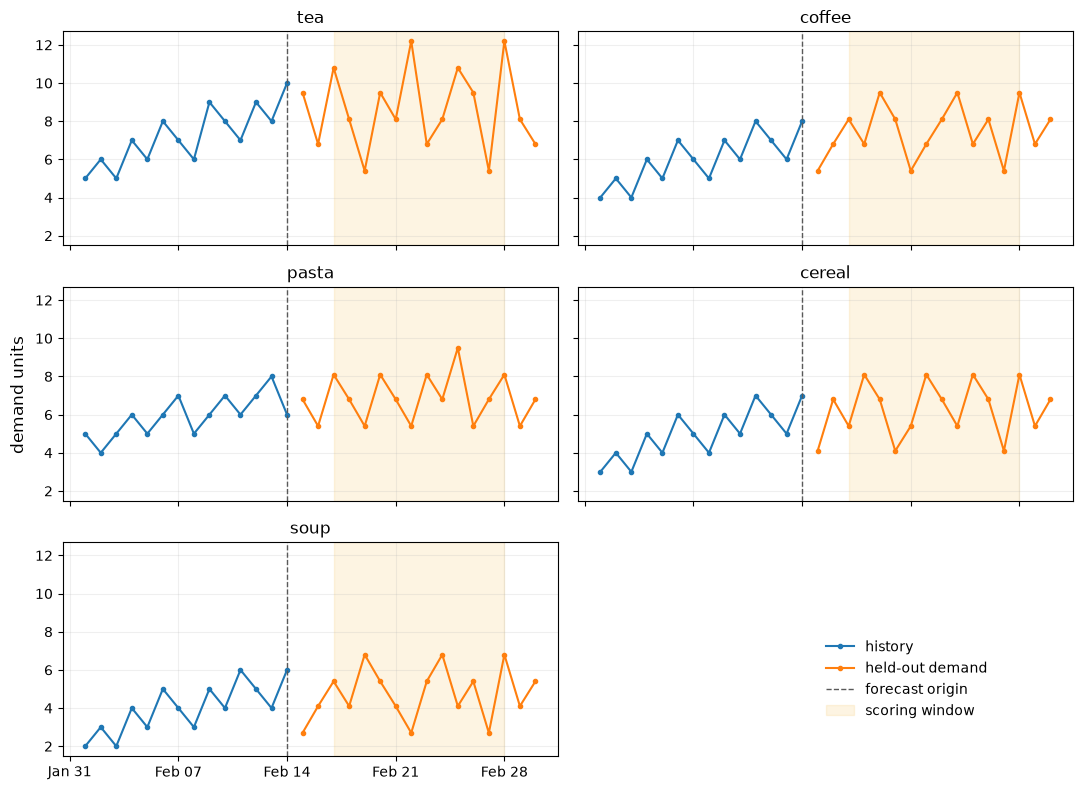

In [8]:
fig, axes = plt.subplots(3, 2, figsize=(11, 8), sharex=True, sharey=True)
for ax, sku in zip(axes.flat, history_values):
    past = history[history['unique_id'].eq(sku)]
    future = holdout[holdout['unique_id'].eq(sku)]
    ax.plot(past['date'], past['y'], marker='o', ms=3, label='history')
    ax.plot(future['date'], future['y'], marker='o', ms=3, label='held-out demand')
    ax.axvline(forecast_origin, color='0.35', ls='--', lw=1, label='forecast origin')
    ax.axvspan(holdout_dates[2], holdout_dates[13], color='#f4b942', alpha=.15, label='scoring window')
    ax.set_title(sku)
    ax.grid(alpha=.2)
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
axes.flat[-1].axis('off')
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right', bbox_to_anchor=(.92, .08), frameon=False)
fig.supylabel('demand units')
fig.tight_layout()
plt.show()

Opening stock and pipeline are fixed across every branch. Every SKU starts with zero backlog and zero in-transit stock, so opening inventory position equals observed on-hand. Lost sales are enabled (`allow_backorders=False`): unmet demand is recorded as shortage/lost-sales evidence and is not carried into a later period as backlog.

With a two-day lead time, an order cannot satisfy same-period demand. Due pipeline stock is received before that period's demand is served, and every positive decision records its expected delivery period explicitly.

In [9]:
# Preserve one stable SKU order in tables and plots.
skus = list(history_values)
opening_stock = pd.DataFrame({
    'unique_id': skus,
    'observed_on_hand': [12.0, 11.0, 10.0, 9.0, 8.0],
})
opening_stock


,unique_id,observed_on_hand
0,tea,12.0
1,coffee,11.0
2,pasta,10.0
3,cereal,9.0
4,soup,8.0


In [10]:
# max_lead_time allocates the two pipeline slots required by this scenario.
# The engine deep-copies this state per branch; the caller-owned object is preserved.
opening_inventory = InventoryStateDataFrame(
    skus, max_lead_time=lead_time, allow_backorders=allow_backorders,
).initialize_from_observed(
    opening_stock, on_hand_column='observed_on_hand', start_date=forecast_origin,
)
opening_inventory


InventoryStateDataFrame(n_skus=5, total_on_hand=50, total_safety_stock=0, total_backorders=0, has_stockout=False, has_backorder=False)

In [11]:
print('Explicit opening state')
print(opening_inventory.inventory_position()[[
    'unique_id', 'on_hand', 'backorders', 'total_in_transit', 'inventory_position',
]].to_string(index=False))


Explicit opening state
unique_id  on_hand  backorders  total_in_transit  inventory_position
      tea     12.0         0.0               0.0                12.0
   coffee     11.0         0.0               0.0                11.0
    pasta     10.0         0.0               0.0                10.0
   cereal      9.0         0.0               0.0                 9.0
     soup      8.0         0.0               0.0                 8.0


Costs are evaluation assumptions, not engine inputs: they value validated event rows after simulation and therefore cannot change physical decisions. We activate only holding, shortage, and ordering costs. Holding cost is charged per ending unit per scored SKU-period; shortage cost is charged per unmet unit; ordering cost is charged per positive SKU order line. Explicit zero unit-order cost means order size has no variable purchasing charge in this tutorial.

No purchase, backlog, waste, terminal-pipeline, or salvage component is silently included. Changing the active components or rates would define a different economic comparison even if the physical runs stayed identical.

In [12]:
# total_cost will fail closed unless this active-component list is explicit.
cost_context = {
    'cost_components': ['holding', 'shortage', 'ordering'],
    'holding_cost_per_unit_period': 0.20,
    'shortage_cost_per_unit': 5.00,
    'order_cost_per_sku_line': 1.50,
    'order_cost_per_unit': 0.00,
}
print(pd.Series(cost_context, name='declared value').to_string())

cost_components                 [holding, shortage, ordering]
holding_cost_per_unit_period                              0.2
shortage_cost_per_unit                                    5.0
order_cost_per_sku_line                                   1.5
order_cost_per_unit                                       0.0


## Build forecast-derived targets outside Stockcast

For each SKU we fit two ETS configurations with Smooth. ETS letters describe the error, trend, and seasonal components in that order:

- **ANN**: additive error, no trend, no seasonality.
- **AAN**: additive error, additive trend, no seasonality.

For each model we request direct cumulative upper prediction quantiles at 90% and 95%. Informally, a horizon-\(h\) upper quantile is a value \(q_p\) for which the fitted model assigns probability \(p\) to cumulative demand over the next \(h\) days being at or below \(q_p\). It is a model-derived uncertainty summary, not a guaranteed service level.

We request two distinct horizons directly:

- the **2-day lead-time target**, later used as a reorder threshold by the custom policy;
- the **4-day protection target**, covering lead time plus the two-day review period for the \(R,S\) policy.

Quantiles are not additive: adding four one-day 95th percentiles would not generally produce the 95th percentile of four-day cumulative demand. Setting `cumulative=True` asks Smooth for the required cumulative distribution directly, so no marginal quantiles are summed.

In [13]:
# This table states the forecast dimensions we deliberately vary.
forecast_design = pd.DataFrame([
    {'ets_model': 'ANN', 'model_change': 'no trend', 'probabilities': '0.90, 0.95'},
    {'ets_model': 'AAN', 'model_change': 'additive trend', 'probabilities': '0.90, 0.95'},
])
print(forecast_design.to_string(index=False))

ets_model   model_change probabilities
      ANN       no trend    0.90, 0.95
      AAN additive trend    0.90, 0.95


This short loop is forecasting work, not a wrapper around the Stockcast comparison API. One model is fitted independently per SKU; there is no pooling or cross-series information sharing. Each catalogue row records the exact model, probability, horizon, dates, provider, package version, source type, and representation used to obtain its direct cumulative target.

The catalogue is the handoff boundary: everything above it estimates forecast-derived information, while the policy cells below consume already-calculated targets. Keeping the boundary as a printed DataFrame makes it possible to audit or replace the forecasting provider without changing engine behavior.

In [14]:
# Accumulate one provenance-complete row per SKU/model/probability tuple.
target_rows = []
for sku in skus:
    # A reset Series gives smooth an explicit integer index without changing values.
    series = history.loc[history['unique_id'].eq(sku), 'y'].reset_index(drop=True)
    for ets_model in ['ANN', 'AAN']:
        # Fit only the declared pre-origin observations for this SKU.
        fitted_model = ES(ets_model).fit(series)
        for probability in [0.90, 0.95]:
            # side='upper' means level=.90/.95 is the upper-tail quantile itself,
            # rather than the upper endpoint of a two-sided central interval.
            lead_forecast = fitted_model.predict(
                h=lead_time, interval='prediction', level=probability,
                side='upper', cumulative=True,
            ).to_dataframe()
            protection_forecast = fitted_model.predict(
                h=protection_horizon, interval='prediction', level=probability,
                side='upper', cumulative=True,
            ).to_dataframe()
            # Each result contains the direct cumulative endpoint at its horizon.
            lead_target = lead_forecast.filter(regex='^upper_').iloc[-1, 0]
            protection_target = protection_forecast.filter(regex='^upper_').iloc[-1, 0]
            # Store both the numeric targets and enough metadata to reproduce them.
            target_rows.append({
                'unique_id': sku,
                'ets_model': ets_model,
                'target_probability': probability,
                'lead_time_target': float(lead_target),
                'lead_time_horizon': lead_time,
                'lead_time_end_date': forecast_origin + pd.Timedelta(days=lead_time),
                'protection_target': float(protection_target),
                'protection_horizon': protection_horizon,
                'target_end_date': forecast_origin + pd.Timedelta(days=protection_horizon),
                'forecast_origin': forecast_origin,
                'forecast_frequency': period_frequency,
                'target_source': 'external_direct',
                'forecast_provider': 'smooth',
                'smooth_version': smooth_version,
                'representation': 'direct_cumulative_upper_quantile',
            })
target_catalogue = pd.DataFrame(target_rows)

Before fitting policies, fail closed if the catalogue is incomplete, duplicated, non-finite, negative, misdated, or internally inconsistent. Exactly 20 rows are required: five SKUs × two ETS configurations × two probabilities. The 95% upper target must not fall below the corresponding 90% target for the same SKU, model, and horizon. These checks validate the declared handoff structure; they do not establish forecast calibration or model quality.

In [15]:
# Enumerate the exact keys that a complete 5 × 2 × 2 catalogue must contain.
expected_keys = pd.MultiIndex.from_product(
    [skus, ['ANN', 'AAN'], [0.90, 0.95]],
    names=['unique_id', 'ets_model', 'target_probability'],
)
actual_keys = pd.MultiIndex.from_frame(target_catalogue[list(expected_keys.names)])
if len(target_catalogue) != 20 or len(actual_keys.unique()) != 20 or set(actual_keys) != set(expected_keys):
    raise ValueError('forecast target catalogue is incomplete or duplicated')
# Scientific inputs must be finite and physically non-negative.
target_values = target_catalogue[['lead_time_target', 'protection_target']]
if not all(math.isfinite(value) for value in target_values.to_numpy().ravel()):
    raise ValueError('forecast targets must be finite')
if (target_values < 0).any().any():
    raise ValueError('forecast targets must be non-negative')
# Target end dates must agree with the stated origin, frequency, and horizons.
if not target_catalogue['lead_time_end_date'].eq(
    forecast_origin + pd.Timedelta(days=lead_time)
).all():
    raise ValueError('lead-time target date does not match its horizon')
if not target_catalogue['target_end_date'].eq(
    forecast_origin + pd.Timedelta(days=protection_horizon)
).all():
    raise ValueError('protection target date does not match its horizon')
# For one-sided upper quantiles, increasing probability cannot lower the target.
ordered = target_catalogue.sort_values('target_probability')
for column in ['lead_time_target', 'protection_target']:
    differences = ordered.groupby(['unique_id', 'ets_model'])[column].diff().dropna()
    if (differences < 0).any():
        raise ValueError(f'95% {column} falls below its 90% counterpart')
print('Catalogue rows per model and probability')
print(target_catalogue.groupby(['ets_model', 'target_probability']).size().to_string())
print('\nCatalogue head (20 rows total: 5 SKUs x 2 models x 2 probabilities)')
print(target_catalogue[[
    'unique_id', 'ets_model', 'target_probability',
    'lead_time_target', 'protection_target',
 ]].head(8).round(2).to_string(index=False))


Catalogue rows per model and probability
ets_model  target_probability
AAN        0.90                  5
           0.95                  5
ANN        0.90                  5
           0.95                  5

Catalogue head (20 rows total: 5 SKUs x 2 models x 2 probabilities)
unique_id ets_model  target_probability  lead_time_target  protection_target
      tea       ANN                0.90             20.82              41.54
      tea       ANN                0.95             21.67              43.22
      tea       AAN                0.90             20.91              41.97
      tea       AAN                0.95             21.46              42.78
   coffee       ANN                0.90             16.87              33.54
   coffee       ANN                0.95             17.62              34.98
   coffee       AAN                0.90             17.40              34.77
   coffee       AAN                0.95             17.92              35.52


The left chart isolates ETS configuration at a fixed 95% upper quantile; the right isolates upper-quantile probability within fixed ANN. Compare bars within a SKU, because each SKU has its own demand scale. These values are forecast-derived inventory inputs—not realized demand forecasts scored with MAE, coverage, or another statistical accuracy metric. Operational evaluation begins only after a policy consumes them.

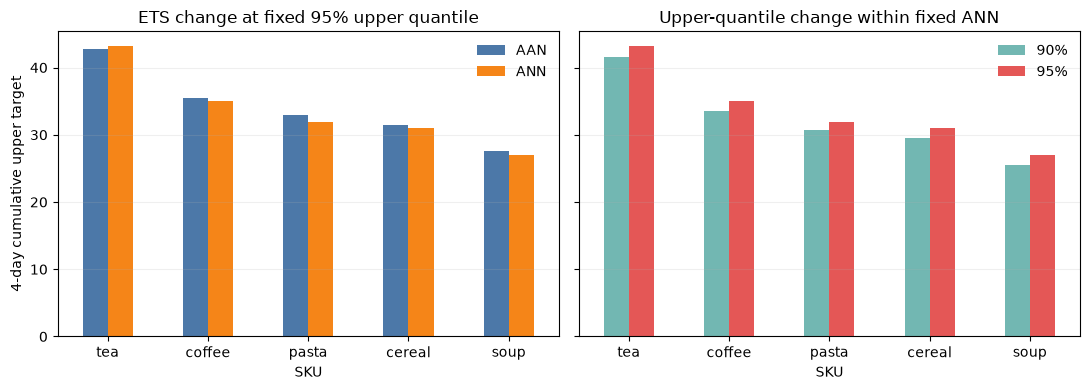

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
model_targets = target_catalogue[target_catalogue['target_probability'].eq(.95)].pivot(
    index='unique_id', columns='ets_model', values='protection_target',
).reindex(skus)
quantile_targets = target_catalogue[target_catalogue['ets_model'].eq('ANN')].pivot(
    index='unique_id', columns='target_probability', values='protection_target',
).reindex(skus)
model_targets.plot.bar(ax=axes[0], color=['#4c78a8', '#f58518'])
quantile_targets.rename(columns={.90: '90%', .95: '95%'}).plot.bar(
    ax=axes[1], color=['#72b7b2', '#e45756'],
)
axes[0].set_title('ETS change at fixed 95% upper quantile')
axes[1].set_title('Upper-quantile change within fixed ANN')
for ax in axes:
    ax.set_xlabel('SKU')
    ax.set_ylabel('4-day cumulative upper target')
    ax.tick_params(axis='x', rotation=0)
    ax.grid(axis='y', alpha=.2)
    ax.legend(title=None, frameon=False)
fig.tight_layout()
plt.show()

## Comparison 1 — change forecast information, keep the policy family fixed

We select ANN-90, ANN-95, and AAN-95. In an \(R,S\) policy, \(R=2\) means the inventory position is reviewed every two days and \(S\) is the SKU-specific 4-day protection target. On a review date the requested quantity is the non-negative gap between \(S\) and current inventory position.

All branches use that same equation, lead time, review period, opening state, demand, shortage mode, timing windows, and costs. The policy's `service_level` must match target probability by API contract, so it is 0.90 for ANN-90 and 0.95 for the other branches. This field validates provenance compatibility; it does not promise that realized fill rate will equal 90% or 95% in sixteen days.

- **ANN-90 vs ANN-95** changes upper-quantile probability and its required matching policy probability.
- **ANN-95 vs AAN-95** changes only the ETS configuration.

Reading any other pair—for example ANN-90 versus AAN-95—changes two forecast dimensions at once and therefore cannot isolate a model-only or probability-only effect.

In [17]:
# Copy three complete five-SKU slices so later policy fits cannot alias the catalogue.
ann90_targets = target_catalogue.query(
    "ets_model == 'ANN' and target_probability == 0.90"
).copy()
ann95_targets = target_catalogue.query(
    "ets_model == 'ANN' and target_probability == 0.95"
).copy()
aan95_targets = target_catalogue.query(
    "ets_model == 'AAN' and target_probability == 0.95"
).copy()

# Fit the first policy from the ANN 90% four-day protection targets.
ann90_policy = OrderUpToPolicy(
    lead_time=lead_time, review_period=review_period, service_level=.90,
    allow_backorders=allow_backorders,
).fit(
    ann90_targets, target_column='protection_target', target_probability=.90,
    protection_horizon=protection_horizon, target_source='external_direct',
    forecast_origin=forecast_origin, forecast_frequency=period_frequency,
    target_end_date_column='target_end_date',
)

In [18]:
# Keep the ANN model and consume its higher-probability 95% target slice.
ann95_policy = OrderUpToPolicy(
    lead_time=lead_time, review_period=review_period, service_level=.95,
    allow_backorders=allow_backorders,
).fit(
    ann95_targets, target_column='protection_target', target_probability=.95,
    protection_horizon=protection_horizon, target_source='external_direct',
    forecast_origin=forecast_origin, forecast_frequency=period_frequency,
    target_end_date_column='target_end_date',
)

# Keep probability at 95% and change only the ETS structure to additive trend.
aan95_policy = OrderUpToPolicy(
    lead_time=lead_time, review_period=review_period, service_level=.95,
    allow_backorders=allow_backorders,
).fit(
    aan95_targets, target_column='protection_target', target_probability=.95,
    protection_horizon=protection_horizon, target_source='external_direct',
    forecast_origin=forecast_origin, forecast_frequency=period_frequency,
    target_end_date_column='target_end_date',
)

In [19]:
# One comparison call gives every branch the same materialized demand rows.
# The engine deep-copies opening inventory and fitted policies per branch,
# preventing one simulation's mutable state from leaking into another.
forecast_comparison = SimulationEngine().run_comparison(
    policies=[ann90_policy, ann95_policy, aan95_policy],
    labels=['ANN 90% + (R,S)', 'ANN 95% + (R,S)', 'AAN 95% + (R,S)'],
    demand_source=holdout, inventory=opening_inventory,
    n_periods=len(holdout_dates), period_frequency=period_frequency,
    initial_decision=initial_decision, warmup_periods=warmup_periods,
    scoring_periods=scoring_periods, settlement_periods=settlement_periods,
    order_during_settlement=order_during_settlement,
    demand_source_name=demand_source_name, random_seed=random_seed,
)

Evaluation reads only validated scoring-window event rows. We pool the panel deliberately (`groupby=[]`), so each output row summarizes one scenario across all five SKUs and twelve scored days. The metrics answer different operational questions:

- `fill_rate`: fulfilled demand units divided by demand units, pooled across the panel;
- `shortage_units`: the additive quantity of demand not fulfilled immediately;
- `avg_on_hand`: mean ending on-hand across scored SKU-period rows;
- `order_units`: additive units requested during the scoring window;
- `total_cost`: only the declared holding, shortage, and SKU-line ordering components.

Pooling is explicit rather than automatically averaging per-SKU service rates. A per-SKU diagnosis would instead pass `groupby=['unique_id']`.

In [20]:
# Evaluate each branch with the identical window, metric list, grain, and costs.
forecast_metric_rows = []
for label, result in forecast_comparison.results.items():
    row = InventoryEvaluator().fit(result, window='scoring').evaluate(
        metrics=[fill_rate, shortage_units, avg_on_hand, order_units, total_cost],
        groupby=[], context=cost_context,
    ).iloc[0].to_dict()
    # Keep the engine label beside its pooled metric row.
    row['scenario'] = label
    forecast_metric_rows.append(row)
forecast_metrics = pd.DataFrame(forecast_metric_rows).set_index('scenario')
print(forecast_metrics.round(3).to_string())

                 fill_rate  shortage_units  avg_on_hand  order_units  total_cost
scenario                                                                        
ANN 90% + (R,S)        1.0             0.0        8.463        400.9     146.562
ANN 95% + (R,S)        1.0             0.0        9.903        400.9     163.832
AAN 95% + (R,S)        1.0             0.0       10.323        400.9     168.878


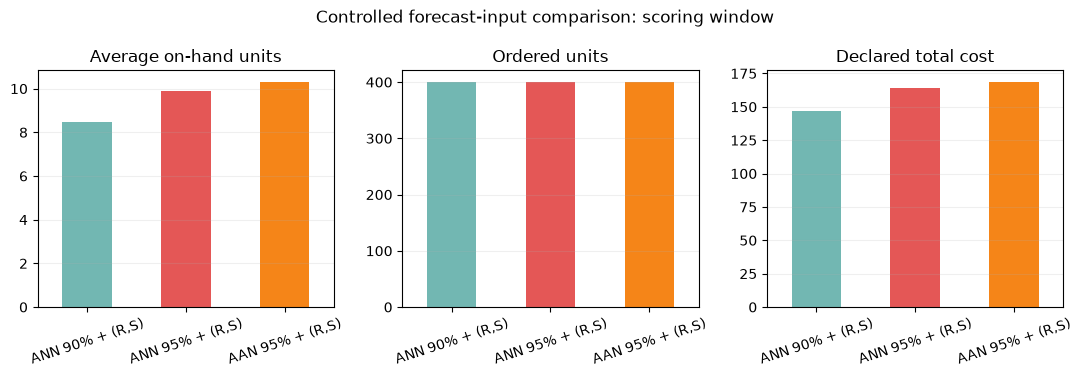

In [21]:
# Plot metrics that visibly separate these no-shortage forecast branches.
forecast_plot_specs = [
    ('avg_on_hand', 'Average on-hand units'),
    ('order_units', 'Ordered units'),
    ('total_cost', 'Declared total cost'),
]
fig, axes = plt.subplots(1, 3, figsize=(11, 3.8))
for ax, (column, title) in zip(axes, forecast_plot_specs):
    forecast_metrics[column].plot.bar(
        ax=ax, color=['#72b7b2', '#e45756', '#f58518'],
    )
    ax.set_title(title)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=18)
    ax.grid(axis='y', alpha=.2)
fig.suptitle('Controlled forecast-input comparison: scoring window')
fig.tight_layout()
plt.show()

**Conditional reading.** All three branches avoid shortages on this path, so fill rate and shortage units are equal in the table. That equality is informative: higher targets do not buy additional fulfilled units in this particular window. Within ANN, 95% raises every target and carries more average stock than 90%. At fixed 95%, AAN changes every target (raising four of five) and increases pooled average stock here. Because order units are equal, the displayed cost difference comes from holding more ending inventory, not purchasing more units.

This does not prove that 90%, 95%, ANN, or AAN is universally better. A longer window, different history, different realized demand, or a larger shortage penalty could change both the operational trade-off and the economically preferred branch.

## The custom policy from Notebook 05, applied to a panel

Notebook 05 orders a fixed quantity when inventory position is at or below a threshold. Inventory position combines what is physically on hand with stock already on order and subtracts backlog; in this lost-sales scenario backlog remains zero. Using position rather than on-hand alone prevents the policy from ignoring replenishment already in the pipeline.

Here the same rule is applied independently to each SKU. A mapping supplies one explicit threshold per SKU because forecast-derived lead-time demand differs across the panel. The policy remains intentionally transparent: if `inventory_position <= reorder_point`, request the declared fixed quantity; otherwise request zero. It does not refit an ETS model, mutate inventory, receive orders, or process demand.

In [22]:
class PanelReorderWhenBelowPolicy(BasePolicy):
    """Order a fixed quantity when a SKU-specific threshold is reached."""
    def __init__(self, reorder_thresholds, order_quantity, parameter_source, **kwargs):
        # BasePolicy owns the shared lead-time, review, service, and shortage fields.
        super().__init__(**kwargs)
        if not isinstance(reorder_thresholds, Mapping) or not reorder_thresholds:
            raise ValueError('reorder_thresholds must be a non-empty mapping')
        # Normalize keys and values once so predict() sees an auditable mapping.
        self.reorder_thresholds = {str(k): float(v) for k, v in reorder_thresholds.items()}
        if any(not math.isfinite(v) or v < 0 for v in self.reorder_thresholds.values()):
            raise ValueError('every reorder threshold must be finite and non-negative')
        # Q is one positive fixed quantity shared by the five SKU rules.
        self.order_quantity = float(order_quantity)
        if not math.isfinite(self.order_quantity) or self.order_quantity <= 0:
            raise ValueError('order_quantity must be finite and positive')
        if not isinstance(parameter_source, str) or not parameter_source.strip():
            raise ValueError('parameter_source must be a non-empty string')
        # This text preserves where the custom thresholds came from.
        self.parameter_source = parameter_source.strip()

    def fit(self, forecast_df=None, **kwargs):
        # There are no coefficients to estimate: the threshold mapping and Q
        # already contain the policy's declared scientific inputs.
        self.fitted_ = True
        return self

    def predict(self, inventory_state_df, current_period=0, **kwargs):
        if not self.fitted_:
            raise ValueError('policy must be fitted before prediction')
        # Read a derived table from inventory; never mutate engine-owned state.
        positions = inventory_state_df.inventory_position()
        sku_column = inventory_state_df.sku_column
        decision = positions[[sku_column, 'inventory_position']].copy()
        # Join each SKU to its own forecast-derived lead-time threshold.
        decision['reorder_point'] = decision[sku_column].map(self.reorder_thresholds)
        if decision['reorder_point'].isna().any():
            missing = decision.loc[decision['reorder_point'].isna(), sku_column].tolist()
            raise ValueError(f'missing reorder thresholds for {missing}')
        # Evaluate the trigger independently for every SKU row.
        decision['order_quantity'] = (
            decision['inventory_position'].le(decision['reorder_point']).astype(float)
            * self.order_quantity
        )
        # target_level is not applicable: this policy orders Q, not up to S.
        decision['target_level'] = math.nan
        decision['order_period'] = current_period
        # The decision requests delivery after the same physical lead time.
        decision['expected_delivery_period'] = current_period + self.lead_time
        return OrderDecision(
            decision[[
                sku_column, 'order_quantity', 'target_level', 'inventory_position',
                'reorder_point', 'order_period', 'expected_delivery_period',
            ]], sku_column=sku_column, lead_time=self.lead_time,
            review_period=self.review_period,
        )

## Comparison 2 — keep ANN-95 information fixed, change policy

Both policies receive information derived from the same ANN-95 catalogue. Holding forecast information fixed does **not** mean forcing both policy equations to consume the same numeric column. Each policy receives the compatible summary from the same fitted model, origin, probability, and history:

- the \(R,S\) rule uses the direct 4-day protection target as order-up-to level \(S\);
- the custom rule uses the direct 2-day lead-time target as reorder threshold and orders fixed \(Q=14\).

The two target roles are printed side by side below. The fixed quantity is a declared tutorial operating assumption, not a value inferred by Stockcast or optimized against the held-out demand. Forecast origin, ETS configuration, probability, provider, demand, state, timing, and costs remain fixed; only decision logic and its compatible target role change.

In [23]:
# Convert the selected ANN-95 lead-time column into SKU -> threshold inputs.
ann95_thresholds = ann95_targets.set_index('unique_id')['lead_time_target'].to_dict()
# Q=14 is explicit scenario evidence and is held constant in later custom runs.
custom_ann95_policy = PanelReorderWhenBelowPolicy(
    reorder_thresholds=ann95_thresholds, order_quantity=14.0,
    parameter_source='smooth ANN 95% direct cumulative 2-day upper targets',
    lead_time=lead_time, review_period=review_period, service_level=.95,
    allow_backorders=allow_backorders,
).fit()
# Display how the same forecast catalogue enters the two policy equations.
policy_inputs = ann95_targets[[
    'unique_id', 'lead_time_target', 'protection_target',
]].rename(columns={
    'lead_time_target': 'custom threshold',
    'protection_target': '(R,S) order-up-to target',
})
policy_inputs['custom fixed quantity'] = custom_ann95_policy.order_quantity
print(policy_inputs.round(2).to_string(index=False))

unique_id  custom threshold  (R,S) order-up-to target  custom fixed quantity
      tea             21.67                     43.22                   14.0
   coffee             17.62                     34.98                   14.0
    pasta             16.15                     31.97                   14.0
   cereal             15.62                     30.98                   14.0
     soup             13.62                     26.98                   14.0


In [24]:
# This second engine call changes policy family while preserving the experiment.
policy_comparison = SimulationEngine().run_comparison(
    policies=[ann95_policy, custom_ann95_policy],
    labels=['ANN 95% + (R,S)', 'ANN 95% + custom'],
    demand_source=holdout, inventory=opening_inventory,
    n_periods=len(holdout_dates), period_frequency=period_frequency,
    initial_decision=initial_decision, warmup_periods=warmup_periods,
    scoring_periods=scoring_periods, settlement_periods=settlement_periods,
    order_during_settlement=order_during_settlement,
    demand_source_name=demand_source_name, random_seed=random_seed,
)

# Reuse the exact scoring, grouping, metric, and cost contract from Comparison 1.
policy_metric_rows = []
for label, result in policy_comparison.results.items():
    row = InventoryEvaluator().fit(result, window='scoring').evaluate(
        metrics=[fill_rate, shortage_units, avg_on_hand, order_units, total_cost],
        groupby=[], context=cost_context,
    ).iloc[0].to_dict()
    row['scenario'] = label
    policy_metric_rows.append(row)
policy_metrics = pd.DataFrame(policy_metric_rows).set_index('scenario')
print(policy_metrics.round(3).to_string())

                  fill_rate  shortage_units  avg_on_hand  order_units  total_cost
scenario                                                                         
ANN 95% + (R,S)        1.00             0.0        9.903        400.9     163.832
ANN 95% + custom       0.83            71.8        3.795        350.0     442.040


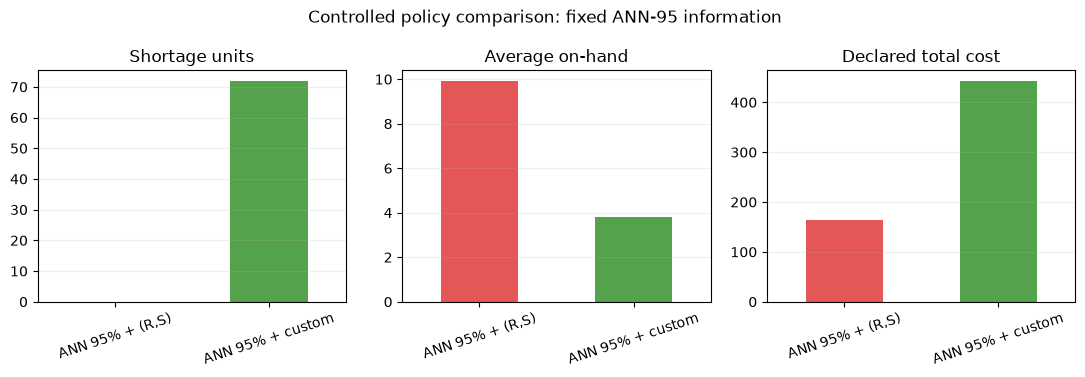

In [25]:
# Show the central service-stock-cost trade-off for the two policy equations.
fig, axes = plt.subplots(1, 3, figsize=(11, 3.8))
for ax, column, title in zip(
    axes, ['shortage_units', 'avg_on_hand', 'total_cost'],
    ['Shortage units', 'Average on-hand', 'Declared total cost'],
):
    policy_metrics[column].plot.bar(ax=ax, color=['#e45756', '#54a24b'])
    ax.set_title(title)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=18)
    ax.grid(axis='y', alpha=.2)
fig.suptitle('Controlled policy comparison: fixed ANN-95 information')
fig.tight_layout()
plt.show()

**Conditional reading.** Under the displayed ANN-95 inputs, the custom rule carries substantially less average stock and has lower declared total cost, but it also leaves some demand unfilled. The \(R,S\) branch avoids shortage in this window by carrying more stock. Lower cost therefore does not mean uniformly better service, and perfect service here does not mean the \(R,S\) rule is universally optimal.

These differences belong to the chosen threshold role, fixed quantity, review cadence, demand, opening state, and cost rates. A larger \(Q\), a different shortage penalty, or another demand path could change the ranking.

## Combined 2 × 2 scenario matrix

Finally we cross two deliberately different forecast inputs—ANN-90 and AAN-95—with both policy families. For each forecast input, \(R,S\) consumes its 4-day target and the custom policy consumes its 2-day target; \(Q=14\) remains fixed. This is the smallest matrix that exposes both main choices and their interaction.

Read it in controlled directions:

- within one forecast input, compare \(R,S\) with custom to study the policy change;
- within one policy family, compare ANN-90 with AAN-95 to study the **combined** forecast-input change;
- do not interpret a diagonal contrast as either a pure forecast or pure policy effect, because both dimensions change.

Unlike Comparison 1, ANN-90 versus AAN-95 changes ETS configuration and probability together. The matrix intentionally describes those two complete forecast scenarios; it does not separate their individual contributions.

In [26]:
# Build the two custom branches from their matching two-day target slices.
custom_ann90_policy = PanelReorderWhenBelowPolicy(
    reorder_thresholds=ann90_targets.set_index('unique_id')['lead_time_target'].to_dict(),
    order_quantity=14.0,
    parameter_source='smooth ANN 90% direct cumulative 2-day upper targets',
    lead_time=lead_time, review_period=review_period, service_level=.90,
    allow_backorders=allow_backorders,
).fit()
custom_aan95_policy = PanelReorderWhenBelowPolicy(
    reorder_thresholds=aan95_targets.set_index('unique_id')['lead_time_target'].to_dict(),
    order_quantity=14.0,
    parameter_source='smooth AAN 95% direct cumulative 2-day upper targets',
    lead_time=lead_time, review_period=review_period, service_level=.95,
    allow_backorders=allow_backorders,
).fit()

# Print the exact forecast-role-policy combinations before running them.
matrix_design = pd.DataFrame([
    ['ANN 90%', '(R,S)', '4-day protection target'],
    ['ANN 90%', 'custom', '2-day threshold; fixed Q=14'],
    ['AAN 95%', '(R,S)', '4-day protection target'],
    ['AAN 95%', 'custom', '2-day threshold; fixed Q=14'],
], columns=['forecast input', 'policy', 'forecast-derived role'])
print(matrix_design.to_string(index=False))

forecast input policy       forecast-derived role
       ANN 90%  (R,S)     4-day protection target
       ANN 90% custom 2-day threshold; fixed Q=14
       AAN 95%  (R,S)     4-day protection target
       AAN 95% custom 2-day threshold; fixed Q=14


In [27]:
# The third comparison call evaluates all four cells on one shared experiment.
matrix_comparison = SimulationEngine().run_comparison(
    policies=[ann90_policy, custom_ann90_policy, aan95_policy, custom_aan95_policy],
    labels=[
        'ANN 90% | (R,S)', 'ANN 90% | custom',
        'AAN 95% | (R,S)', 'AAN 95% | custom',
    ],
    demand_source=holdout, inventory=opening_inventory,
    n_periods=len(holdout_dates), period_frequency=period_frequency,
    initial_decision=initial_decision, warmup_periods=warmup_periods,
    scoring_periods=scoring_periods, settlement_periods=settlement_periods,
    order_during_settlement=order_during_settlement,
    demand_source_name=demand_source_name, random_seed=random_seed,
)

# Apply one evaluation contract to every matrix cell.
matrix_metric_rows = []
for label, result in matrix_comparison.results.items():
    row = InventoryEvaluator().fit(result, window='scoring').evaluate(
        metrics=[fill_rate, shortage_units, avg_on_hand, order_units, total_cost],
        groupby=[], context=cost_context,
    ).iloc[0].to_dict()
    row['scenario'] = label
    matrix_metric_rows.append(row)
matrix_metrics = pd.DataFrame(matrix_metric_rows).set_index('scenario')
print(matrix_metrics.round(3).to_string())

                  fill_rate  shortage_units  avg_on_hand  order_units  total_cost
scenario                                                                         
ANN 90% | (R,S)       1.000             0.0        8.463        400.9     146.562
ANN 90% | custom      0.830            71.8        3.795        350.0     442.040
AAN 95% | (R,S)       1.000             0.0       10.323        400.9     168.878
AAN 95% | custom      0.863            57.8        3.910        364.0     374.920


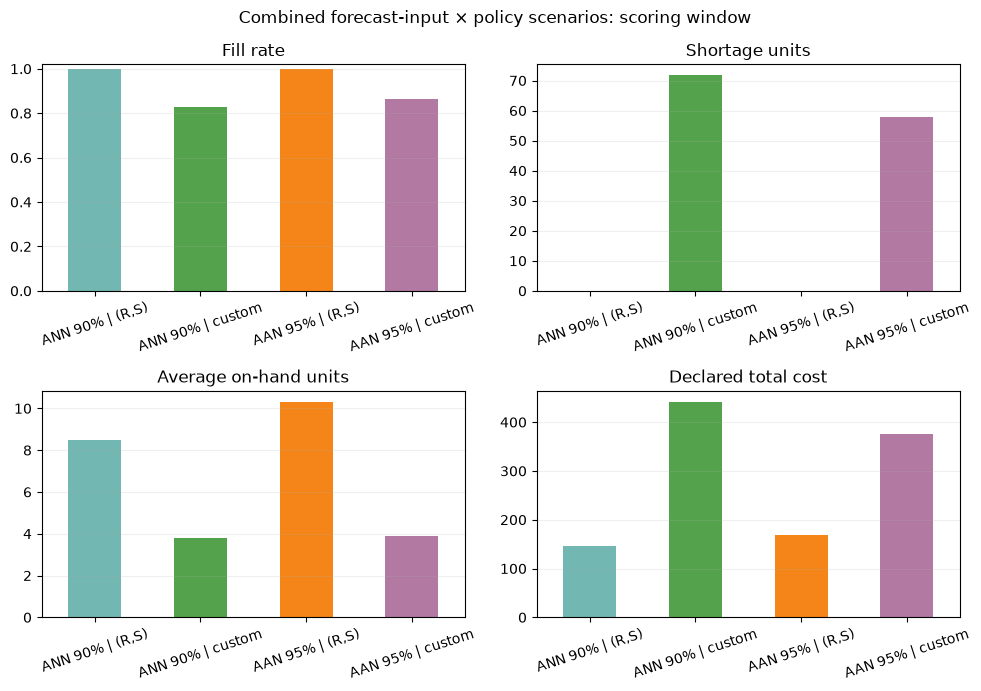

In [28]:
# Use a shared color per matrix cell across all four aggregate metrics.
matrix_plot_specs = [
    ('fill_rate', 'Fill rate', (0, 1.02)),
    ('shortage_units', 'Shortage units', None),
    ('avg_on_hand', 'Average on-hand units', None),
    ('total_cost', 'Declared total cost', None),
]
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, (column, title, ylim) in zip(axes.flat, matrix_plot_specs):
    matrix_metrics[column].plot.bar(
        ax=ax, color=['#72b7b2', '#54a24b', '#f58518', '#b279a2'],
    )
    ax.set_title(title)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=18)
    ax.grid(axis='y', alpha=.2)
    if ylim:
        ax.set_ylim(*ylim)
fig.suptitle('Combined forecast-input × policy scenarios: scoring window')
fig.tight_layout()
plt.show()

A compact event view connects aggregate bars to the validated engine ledger. We aggregate additive fields over SKUs for each scenario-date, retain the first scoring date for every scenario, and then retain any scoring date with a shortage. This is a diagnostic slice rather than a replacement for the complete event table.

The columns follow the physical flow: `received` is stock whose lead time expires on that date; `demand` is the common exogenous input; `ordered` is the policy request; `ending_on_hand` is stock remaining after receipts and demand; `on_order_end` is the closing pipeline; and `shortage` is demand not immediately fulfilled. Demand must match across scenarios, while orders, arrivals, stock, pipeline, and shortages are conditional outcomes of the forecast-policy combination.

In [29]:
# Collect the same public scoring-window event view from every matrix branch.
event_parts = []
for label, result in matrix_comparison.results.items():
    # The public accessor returns a defensive copy of validated scoring events.
    scoring = result.to_event_frame(window='scoring')
    scoring['scenario'] = label
    event_parts.append(scoring)
# Concatenation preserves scenario labels before portfolio aggregation.
matrix_events = pd.concat(event_parts, ignore_index=True)
# These quantities are additive across SKUs at a common date and frequency.
portfolio_events = matrix_events.groupby(['scenario', 'date'], as_index=False).agg(
    demand=('demand', 'sum'), ordered=('order_quantity', 'sum'),
    received=('received_units', 'sum'), ending_on_hand=('ending_on_hand', 'sum'),
    on_order_end=('on_order_end', 'sum'), shortage=('shortage_units', 'sum'),
)
# Keep a common baseline row plus every date where service was missed.
first_scoring_date = portfolio_events['date'].min()
evidence = portfolio_events[
    portfolio_events['date'].eq(first_scoring_date) | portfolio_events['shortage'].gt(0)
].copy()
numeric_columns = evidence.select_dtypes(include='number').columns
evidence[numeric_columns] = evidence[numeric_columns].round(2)
print(evidence.to_string(index=False))

        scenario       date  demand  ordered  received  ending_on_hand  on_order_end  shortage
 AAN 95% | (R,S) 2026-02-17    37.8     48.8    120.23           83.63          48.8       0.0
AAN 95% | custom 2026-02-17    37.8     56.0     70.00           33.40          56.0       0.0
AAN 95% | custom 2026-02-18    33.9      0.0      0.00            6.20          56.0       6.7
AAN 95% | custom 2026-02-19    33.9     70.0     56.00           29.40          70.0       1.1
AAN 95% | custom 2026-02-20    35.2      0.0      0.00            4.10          70.0       9.9
AAN 95% | custom 2026-02-22    35.2      0.0      0.00           15.40          42.0       6.3
AAN 95% | custom 2026-02-23    35.2     70.0     42.00           24.90          70.0       2.7
AAN 95% | custom 2026-02-24    36.6      0.0      0.00            1.40          70.0      13.1
AAN 95% | custom 2026-02-26    35.2      0.0      0.00            5.00          56.0       8.1
AAN 95% | custom 2026-02-28    44.7      0.0      

## Takeaway

A fair operational comparison names both the change and the controls. Here, controlled forecast contrasts hold the policy family and inventory experiment fixed; the controlled policy contrast holds selected forecast-derived information and the inventory experiment fixed. The final matrix exposes interactions, but a diagonal comparison changes forecast information and policy together and cannot identify which change caused the difference.

A reusable comparison checklist is therefore:

1. declare history, held-out demand, opening state, frequency, timing windows, shortage mode, and costs;
2. record forecast-target model, probability, horizon, dates, provider, representation, and source;
3. name exactly what changes and what remains fixed;
4. isolate mutable state and policy objects while sharing materialized demand;
5. evaluate the same validated window, grain, metrics, and costs;
6. interpret service, stock, orders, and cost together rather than choosing a winner from one metric.

These are reproducible conditional outcomes under one transparent tutorial scenario. They are not statistical model-selection evidence and do not show that an ETS configuration, upper-quantile probability, or replenishment policy is universally better.